# Cohort FACTM run

Notebook uruchamia porownanie baseline FACTM vs Cohort FACTM na `raw_data_cohort.csv`.

- `group` jest traktowane jako kohorta,
- zapisuje wykres ELBO do `cohort_elbo_plot.png`,
- zapisuje sekwencje ELBO do `cohort_elbo_sequence.csv`.


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import FACTModel
from src.enums import Likelihood, WPrior, ZPrior
from src.model_config import CohortPriorConfig, ModelConfig, SimpleViewConfig
from src.views import Views


In [2]:
data_path = Path("raw_data_cohort.csv")
if not data_path.exists():
    data_path = Path("data") / "raw_data_cohort.csv"
if not data_path.exists():
    raise FileNotFoundError("Nie znaleziono raw_data_cohort.csv")

df = pd.read_csv(data_path)
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print("Views:", sorted(df["view"].unique().tolist()))
print("Groups:", df["group"].nunique())
df.head()


Rows: 2177110
Columns: ['view', 'group', 'feature', 'sample', 'value']
Views: ['DNA', 'IF_dens', 'IF_inter', 'RNA']


Groups: 7


,view,group,feature,sample,value
0,DNA,BC1,feature0_view0,IMMU-BC1-0164-FIXT-01,0.0
1,DNA,BC1,feature1_view0,IMMU-BC1-0164-FIXT-01,0.0
2,DNA,BC1,feature2_view0,IMMU-BC1-0164-FIXT-01,0.0
3,DNA,BC1,feature3_view0,IMMU-BC1-0164-FIXT-01,0.0
4,DNA,BC1,feature4_view0,IMMU-BC1-0164-FIXT-01,0.0


In [3]:
# Build aligned sample order and cohort labels
samples = np.sort(df["sample"].unique())
sample_group = (
    df[["sample", "group"]]
    .drop_duplicates(subset=["sample"])
    .set_index("sample")
    .reindex(samples)
)
if sample_group["group"].isna().any():
    raise ValueError("Brak group dla czesci probek")

cohort_labels = sample_group["group"].astype(str).to_numpy()
cohort_codes, cohort_names = pd.factorize(cohort_labels, sort=True)

# Build simple views (all views as matrices N x D)
view_names = sorted(df["view"].unique())
view_arrays = []
for view_name in view_names:
    sub = df[df["view"] == view_name]
    pivot = sub.pivot_table(
        index="sample",
        columns="feature",
        values="value",
        aggfunc="first",
    ).reindex(samples)
    arr = pivot.fillna(0.0).to_numpy(dtype=float)
    view_arrays.append(arr)
    print(f"{view_name}: {arr.shape}")

views = Views.from_list(view_arrays, cohorts=cohort_codes)
print("N:", views.N, "simple views:", views.num_simple)
print("Cohorts:", {int(i): str(name) for i, name in enumerate(cohort_names)})


DNA: (1814, 601)
IF_dens: (1814, 53)


IF_inter: (1814, 606)


RNA: (1814, 310)
N: 1814 simple views: 4
Cohorts: {0: 'BC1', 1: 'BC2', 2: 'BC3', 3: 'NSCLC', 4: 'NSCLC2', 5: 'SCCHN1', 6: 'SCCHN3'}


In [4]:
K = 6
max_iter = 25
simple_cfgs = [
    SimpleViewConfig(likelihood=Likelihood.NORMAL, w_prior=WPrior.ARD)
    for _ in range(views.num_simple)
]

baseline_config = ModelConfig(
    simple_view_configs=simple_cfgs,
    structured_view_configs=[],
    z_priors=[ZPrior.STD_NORMAL] * K,
    node_update_factor=1.0,
)

t0 = time.time()
model_baseline = FACTModel(views=views, K=K, model_config=baseline_config, seed=0)
model_baseline.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
print("Baseline runtime [s]:", round(time.time() - t0, 2))


Pretraining FA


Fitting model


  0%|                                                                                           | 0/25 [00:00<?, ?it/s]

  4%|███▎                                                                               | 1/25 [00:07<03:08,  7.85s/it]

  8%|██████▋                                                                            | 2/25 [00:13<02:33,  6.68s/it]

...

 92%|███████████████████████████████████████████████████████████████████████████▍      | 23/25 [02:20<00:12,  6.08s/it]

 96%|██████████████████████████████████████████████████████████████████████████████▋   | 24/25 [02:27<00:06,  6.06s/it]

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [02:32<00:00,  5.97s/it]

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [02:32<00:00,  6.11s/it]

Baseline runtime [s]: 162.21


In [5]:
cohort_config = ModelConfig(
    simple_view_configs=simple_cfgs,
    structured_view_configs=[],
    z_priors=[ZPrior.COHORT] * K,
    node_update_factor=1.0,
    cohort_prior_config=CohortPriorConfig(
        pi=0.5,
        a_lambda=1.0,
        b_lambda=1.0,
        a0_tau=1.0,
        b0_tau=1.0,
    ),
)

t1 = time.time()
model_cohort = FACTModel(views=views, K=K, model_config=cohort_config, seed=0)
model_cohort.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
print("Cohort runtime [s]:", round(time.time() - t1, 2))


Pretraining FA


Fitting model


  0%|                                                                                           | 0/25 [00:00<?, ?it/s]

  4%|███▎                                                                               | 1/25 [00:06<02:32,  6.36s/it]

  8%|██████▋                                                                            | 2/25 [00:12<02:22,  6.20s/it]

...

 92%|███████████████████████████████████████████████████████████████████████████▍      | 23/25 [02:33<00:14,  7.03s/it]

 96%|██████████████████████████████████████████████████████████████████████████████▋   | 24/25 [02:41<00:07,  7.21s/it]

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [02:48<00:00,  7.04s/it]

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [02:48<00:00,  6.72s/it]

Cohort runtime [s]: 174.55


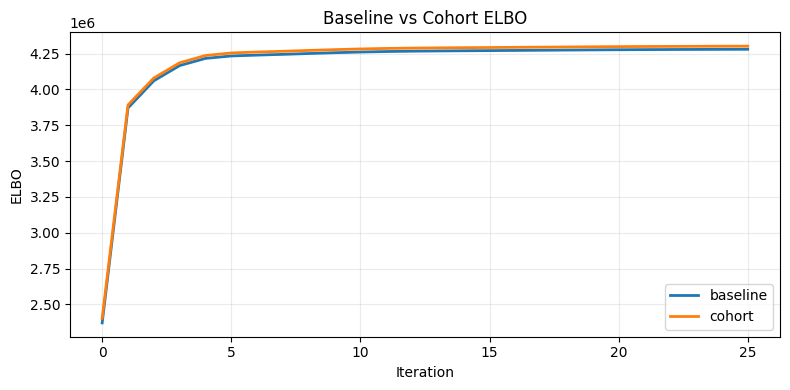

Baseline ELBO first/last: 2371146.8088088585 4280465.481256498
Cohort   ELBO first/last: 2403348.75067587 4302226.702817463


In [6]:
elbo_baseline = np.asarray(model_baseline.elbo_sequence, dtype=float)
elbo_cohort = np.asarray(model_cohort.elbo_sequence, dtype=float)

n = int(max(len(elbo_baseline), len(elbo_cohort)))
baseline_pad = np.full(n, np.nan, dtype=float)
cohort_pad = np.full(n, np.nan, dtype=float)
baseline_pad[: len(elbo_baseline)] = elbo_baseline
cohort_pad[: len(elbo_cohort)] = elbo_cohort

elbo_df = pd.DataFrame(
    {
        "iter": np.arange(n, dtype=int),
        "elbo_baseline": baseline_pad,
        "elbo_cohort": cohort_pad,
    }
)
elbo_df.to_csv("cohort_elbo_sequence.csv", index=False)

plt.figure(figsize=(8, 4))
plt.plot(elbo_baseline, label="baseline", linewidth=2)
plt.plot(elbo_cohort, label="cohort", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.title("Baseline vs Cohort ELBO")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("cohort_elbo_plot.png", dpi=160)
plt.show()

print("Baseline ELBO first/last:", float(elbo_baseline[0]), float(elbo_baseline[-1]))
print("Cohort   ELBO first/last:", float(elbo_cohort[0]), float(elbo_cohort[-1]))


View0 MSE baseline: 0.0033666593834592163
View0 MSE cohort:   0.0033666561098619706


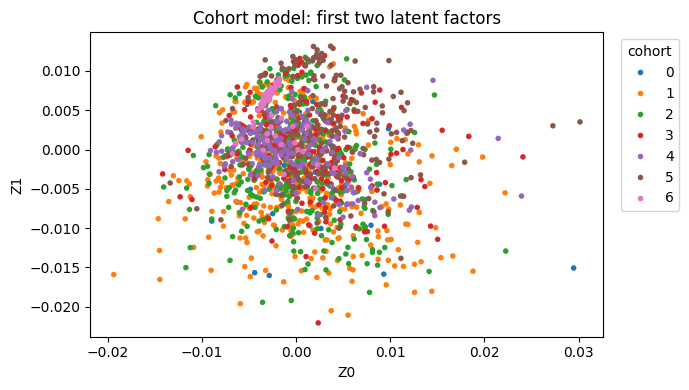

In [7]:
if views.num_simple > 0:
    y0 = views.simple[0].data
    pred0_baseline = model_baseline.get_predictions_FA(0)
    pred0_cohort = model_cohort.get_predictions_FA(0)
    mse_baseline = float(np.nanmean((y0 - pred0_baseline) ** 2))
    mse_cohort = float(np.nanmean((y0 - pred0_cohort) ** 2))
    print("View0 MSE baseline:", mse_baseline)
    print("View0 MSE cohort:  ", mse_cohort)

z = model_cohort.get_latent_factors()
if z.shape[1] >= 2:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(x=z[:, 0], y=z[:, 1], hue=cohort_codes, palette="tab10", s=16, linewidth=0)
    plt.title("Cohort model: first two latent factors")
    plt.xlabel("Z0")
    plt.ylabel("Z1")
    plt.legend(title="cohort", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## Variance explained diagnostics (baseline vs cohort)

Dodatkowe wykresy analogiczne do `run_factm_models.ipynb`.


In [8]:
var_view_baseline = np.asarray(model_baseline.fa.variance_explained_per_view(), dtype=float)
var_view_cohort = np.asarray(model_cohort.fa.variance_explained_per_view(), dtype=float)
var_factor_baseline = np.asarray(model_baseline.fa.variance_explained_per_factor(), dtype=float)
var_factor_cohort = np.asarray(model_cohort.fa.variance_explained_per_factor(), dtype=float)
var_factor_view_baseline = np.asarray(model_baseline.fa.variance_explained_per_factor_view(), dtype=float)
var_factor_view_cohort = np.asarray(model_cohort.fa.variance_explained_per_factor_view(), dtype=float)

var_view_df = pd.DataFrame(
    {
        "view": view_names,
        "baseline": var_view_baseline,
        "cohort": var_view_cohort,
    }
)
var_factor_df = pd.DataFrame(
    {
        "factor": np.arange(K, dtype=int),
        "baseline": var_factor_baseline,
        "cohort": var_factor_cohort,
    }
)
print("Variance explained per view:")
print(var_view_df)
print("\nVariance explained per factor:")
print(var_factor_df)


Variance explained per view:
       view  baseline    cohort
0       DNA  0.000792  0.000793
1   IF_dens  0.291543  0.291779
2  IF_inter  0.385867  0.385794
3       RNA  0.415045  0.415029

Variance explained per factor:
   factor  baseline    cohort
0       0  0.015026  0.014295
1       1  0.101430  0.101910
2       2  0.014203  0.014026
3       3  0.046381  0.046408
4       4  0.103491  0.103344
5       5  0.060190  0.060311


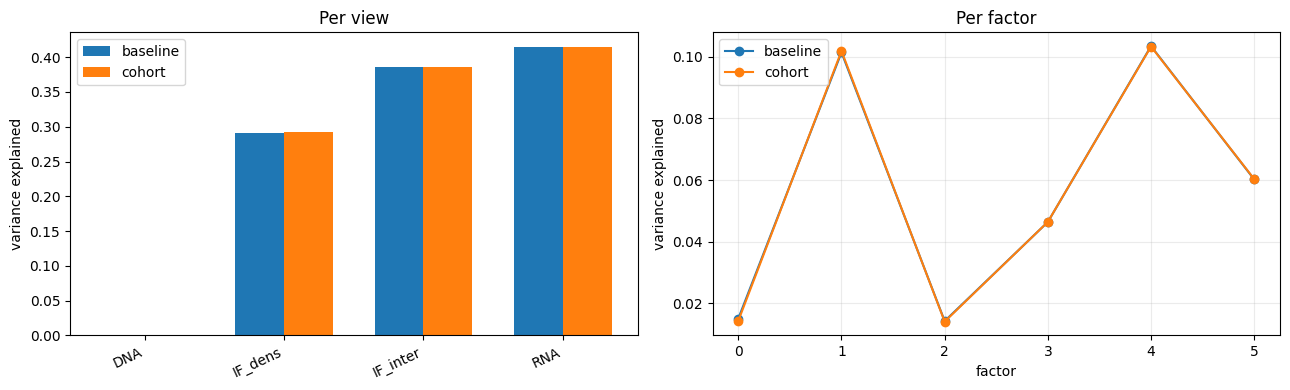

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

xv = np.arange(len(view_names), dtype=int)
w = 0.35
axes[0].bar(xv - w / 2, var_view_baseline, width=w, label="baseline")
axes[0].bar(xv + w / 2, var_view_cohort, width=w, label="cohort")
axes[0].set_xticks(xv)
axes[0].set_xticklabels(view_names, rotation=25, ha="right")
axes[0].set_ylabel("variance explained")
axes[0].set_title("Per view")
axes[0].legend()

xf = np.arange(K, dtype=int)
axes[1].plot(xf, var_factor_baseline, marker="o", label="baseline")
axes[1].plot(xf, var_factor_cohort, marker="o", label="cohort")
axes[1].set_xlabel("factor")
axes[1].set_ylabel("variance explained")
axes[1].set_title("Per factor")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig("cohort_variance_summary.png", dpi=160)
plt.show()


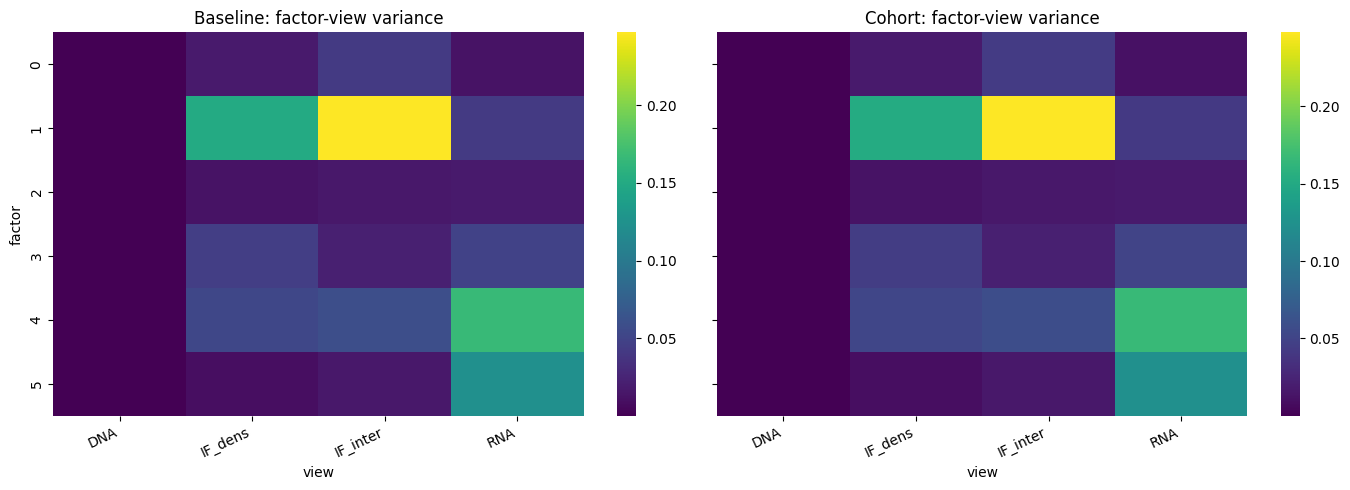

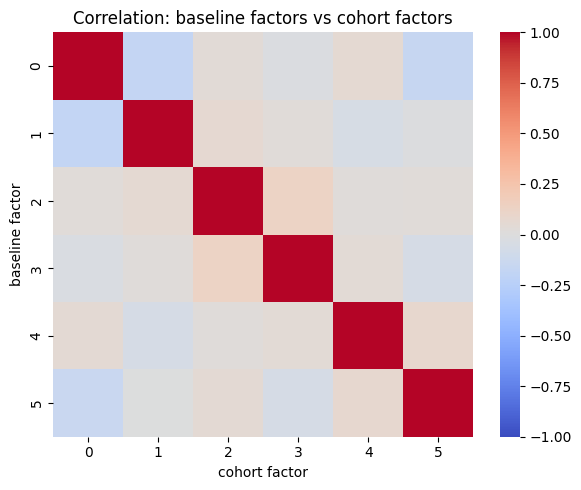

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.heatmap(var_factor_view_baseline, cmap="viridis", ax=axes[0])
axes[0].set_title("Baseline: factor-view variance")
axes[0].set_xlabel("view")
axes[0].set_ylabel("factor")
axes[0].set_xticks(np.arange(len(view_names)) + 0.5)
axes[0].set_xticklabels(view_names, rotation=25, ha="right")

sns.heatmap(var_factor_view_cohort, cmap="viridis", ax=axes[1])
axes[1].set_title("Cohort: factor-view variance")
axes[1].set_xlabel("view")
axes[1].set_xticks(np.arange(len(view_names)) + 0.5)
axes[1].set_xticklabels(view_names, rotation=25, ha="right")

plt.tight_layout()
plt.savefig("cohort_variance_factor_view_heatmap.png", dpi=160)
plt.show()

z_baseline = model_baseline.get_latent_factors()
z_cohort = model_cohort.get_latent_factors()
corr_full = np.corrcoef(z_baseline.T, z_cohort.T)
corr_block = corr_full[:K, K:]

plt.figure(figsize=(6, 5))
sns.heatmap(corr_block, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation: baseline factors vs cohort factors")
plt.xlabel("cohort factor")
plt.ylabel("baseline factor")
plt.tight_layout()
plt.savefig("cohort_latent_correlation_heatmap.png", dpi=160)
plt.show()
